# Pattern 1 — Prompt Chaining

## The idea in one line
**Run LLM calls in sequence — the output of one becomes the input of the next.**

## When to use it
Use prompt chaining when a task breaks cleanly into **ordered steps** you can define in advance:

- Translate a document → check the translation → polish the result
- Draft an email → fix grammar → make the tone more friendly
- Generate code → run a linter → add documentation

Each step is a small, focused LLM call. Because each step is simpler than the whole task, each one is more reliable.

## When *not* to use it
If the steps aren't known in advance, or if the order depends on the input, use **routing** or an **agent** instead.

## The shape of the graph

![Prompt chaining workflow](../images/prompt_chain.avif)


```
START → generate_joke → (has punchline?) ──► END
                     │
                     └──► improve_joke → polish_joke → END
```

A small **gate function** checks the output between steps and decides whether to continue or stop. That's the only branching in this pattern.


In [13]:
# Setup — run this first in every notebook
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")

llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    temperature=1.0,
    max_retries=2,
    google_api_key=os.getenv("GEMINI_API_KEY"),
)


## Example 1 — The docs example (joke writer)

This is the canonical example from the LangGraph docs:
1. Generate a joke
2. If it doesn't look like it has a punchline (no `?` or `!`), improve it
3. Polish it with a twist

We define the **state** (a TypedDict — the shared data that flows through the graph), then one function per node.


In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


def generate_joke(state: State):
    """First LLM call — generate an initial joke."""
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content[0]['text']}


def check_punchline(state: State):
    """Gate function — does the joke look like it has a punchline?"""
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call — add wordplay to make it funnier."""
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content[0]['text']}


def polish_joke(state: State):
    """Third LLM call — add a surprising twist."""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content[0]['text']}


workflow = StateGraph(State)
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke",
    check_punchline,
    {"Fail": "improve_joke", "Pass": END},
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

graph = workflow.compile()


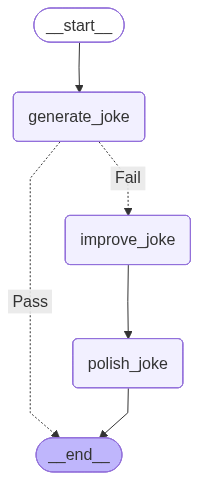

In [15]:
# Visualize the graph (renders as an image in Jupyter)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [17]:
state = graph.invoke({"topic": "cats"})

print("Initial joke:")
print(state["joke"])
print()
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print()
    print("Final joke:")
    print(state["final_joke"])
else:
    print("(The first joke already had a punchline — no improvement needed.)")


Initial joke:
Why was the cat sitting on the computer?

Because it wanted to keep an eye on the mouse!

(The first joke already had a punchline — no improvement needed.)


## Example 2 — Real use case: email refiner

A more practical chain. The user writes a rough message; we:

1. **Draft** a professional version
2. **Check grammar**
3. **Adjust tone** to friendly + concise

No branching this time — just a straight sequence, which is the most common shape.


In [18]:
class EmailState(TypedDict):
    rough_idea: str
    draft: str
    grammar_fixed: str
    final_email: str


def draft_email(state: EmailState):
    msg = llm.invoke(
        f"Turn this rough note into a professional email:\n\n{state['rough_idea']}"
    )
    return {"draft": msg.content[0]['text']}


def fix_grammar(state: EmailState):
    msg = llm.invoke(
        f"Fix any grammar or spelling issues. Return only the corrected email:\n\n{state['draft']}"
    )
    return {"grammar_fixed": msg.content[0]['text']}


def friendly_tone(state: EmailState):
    msg = llm.invoke(
        "Rewrite this email so the tone is warm and friendly, but keep it concise. "
        f"Return only the email:\n\n{state['grammar_fixed']}"
    )
    return {"final_email": msg.content}


email_wf = StateGraph(EmailState)
email_wf.add_node("draft_email", draft_email)
email_wf.add_node("fix_grammar", fix_grammar)
email_wf.add_node("friendly_tone", friendly_tone)
email_wf.add_edge(START, "draft_email")
email_wf.add_edge("draft_email", "fix_grammar")
email_wf.add_edge("fix_grammar", "friendly_tone")
email_wf.add_edge("friendly_tone", END)

graph = email_wf.compile()


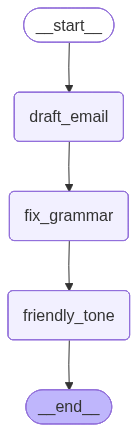

In [19]:
# Visualize the graph (renders as an image in Jupyter)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [20]:
result = graph.invoke({
    "rough_idea": "tell my manager i cant come tomorow i am sik and will finish the report on monday"
})

print("DRAFT:\n", result["draft"], "\n")
print("GRAMMAR FIXED:\n", result["grammar_fixed"], "\n")
print("FINAL:\n", result["final_email"])


DRAFT:
 Here are a few options, ranging from standard professional to a bit more brief.

### Option 1: Professional & Clear (Best for most situations)
**Subject:** Absence Tomorrow - [Your Name]

Hi [Manager's Name],

Please accept this email as notification that I am unable to come into work tomorrow, [Date], as I am feeling unwell. 

Regarding the report I am working on, I plan to have it finalized and submitted to you first thing Monday morning. 

Thank you for understanding.

Best regards,

[Your Name]

***

### Option 2: Short & Direct
**Subject:** Sick Leave - [Your Name] - [Date]

Hi [Manager's Name],

I’m writing to let you know that I’ve come down with something and will be out sick tomorrow. I will complete the report and send it over to you on Monday.

I apologize for any inconvenience.

Best,

[Your Name]

***

### Option 3: If you are sending this via Slack or Teams
Hi [Manager's Name], I’m feeling under the weather and will need to take tomorrow off to recover. I’ll make 

## Takeaways

- A chain is the simplest workflow: nodes connected in a line.
- Each node does **one small thing well**.
- Optional **gate functions** let you skip steps when they aren't needed.
- The `State` TypedDict is the shared memory across the whole graph.

## Try it yourself

- Build a 3-step chain: **title generator → outline generator → first paragraph**.
- Add a gate that skips the outline step if the title is shorter than 5 words.
